In [51]:

"""
This script generates synthetic 2D images of a star-shaped pattern with varying signal-to-noise ratios (SNRs) 
and corresponding ground truth images. The generated data is saved in HDF5 format for further processing 
(e.g., by a convolutional neural network). Additionally, optional TIFF files and an ImageJ macro can be 
generated for visualization and analysis.

Usage:
    Run the script directly to generate the synthetic data and save it in the specified formats. 
    Uncomment the optional sections to generate TIFF files and an ImageJ macro.
    - The random number generator is fixed with a seed for repeatable executions.
    - The script assumes the working directory is writable for saving the output files.
    - The optional ImageJ macro is used for automated application of ThunderSTORM multi-emitter fitting.
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy.ndimage as ndi

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

# ------------ Data generation parameters  --------------
MONTE_CARLO_SAMPLES = 10
PSFW = 2
WIDTH = 50
HEIGTH = 50
BCKG = 3
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = np.logspace(0, 3, 11)

# ------------ Helper functions  --------------


def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    img = RNG.normal(noise_mean, noise_std,
                  h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    img = (img - np.min(img))
    img = img/np.sum(img)
    return img


def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = (scale-1)/2
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)


# ------------ Main part  --------------
# snrs_mc = np.kron(snrs, np.ones(MONTE_CARLO_SAMPLES))
# Generate coordinates of the star-shaped pattern.
# xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
#                for i in range(8) for r in [6, 12, 18]])
xyi = np.array([(25,25,1e6)])

img = generate_image(xyi, BCKG, 1, PSFW, HEIGTH, WIDTH)
imggt = generate_gt_image(upscale_xyi(xyi), 200, 200)

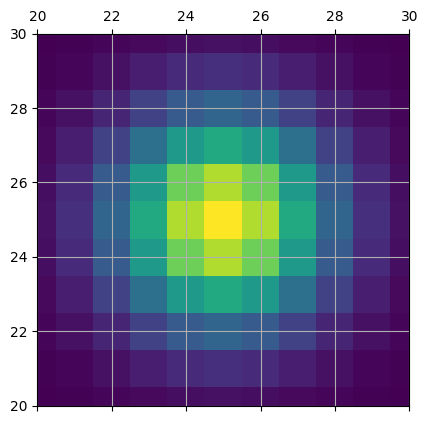

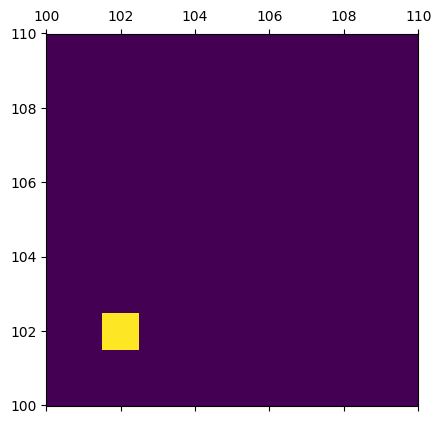

In [52]:
plt.matshow(img)
plt.xlim(20,30)
plt.ylim(20,30)
plt.grid()
plt.show()

plt.matshow(imggt)
plt.xlim(100,110)
plt.ylim(100,110)
plt.show()

In [53]:
25*4+1.5

101.5

In [54]:
np.save('single_psf.npy', img)

In [55]:
imgcnn = np.load('single_psf_cnnout.npy')[0]

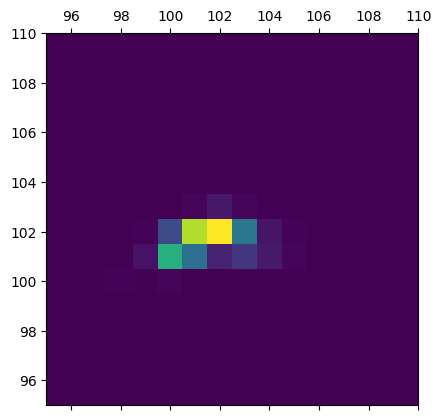

In [56]:
plt.matshow(imgcnn)
plt.xlim(95,110)
plt.ylim(95,110)
plt.show()

In [57]:
def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        #for zero-array, skip normalization (to avoid zero-division)
        return np.zeros_like(a)
    return asu/norm
    
def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel()) #+ 1e-9 #tested distribution
    if prevent_infty:
        imAn += 1e-10 #this is the value that adds the CNN to dark pixels, this is the typical background value for CNN output
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel()) #+ 1e-9 #reference distribution    
    #order here is important, first comes reference
    return entropy(imBn/np.sum(imBn), imAn/np.sum(imAn), base=2)

BLUR = 2
#metrics of interest
metrics = {
    'MAE' : lambda x, y : MAE(x, y, BLUR),
    'KLD' : lambda x, y : KLD(x, y, BLUR)
}

MAE(imgcnn, imggt)

7.006647450529975e-06